# Solution 3C: Tree-Based Models
**BUSI 722: Data-Driven Finance II**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

df = pd.read_parquet("merged.parquet")
df = df[df["month"] >= "2023-01"].copy()
print(f"Loaded: {len(df):,} rows, {df['ticker'].nunique()} tickers")

FEATURES = ["momentum", "lag_month", "pb", "roe", "grossmargin",
            "assetturnover", "leverage", "asset_growth", "gp_to_assets"]

Loaded: 103,931 rows, 3866 tickers


In [2]:
# Rank features and target cross-sectionally each month
for feat in FEATURES:
    df[f"{feat}_rank"] = df.groupby("month")[feat].transform(lambda x: x.rank(pct=True))
df["ret_rank"] = df.groupby("month")["return"].transform(lambda x: x.rank(pct=True))
feat_rank_cols = [f"{f}_rank" for f in FEATURES]

# Train/test split
train = df[(df["month"] >= "2023-01") & (df["month"] <= "2024-12")].copy()
test = df[df["month"] >= "2025-01"].copy()
X_train = train[feat_rank_cols].values
y_train = train["ret_rank"].values
X_test = test[feat_rank_cols].values
print(f"Train: {len(train):,} rows ({train['month'].min()} to {train['month'].max()})")
print(f"Test:  {len(test):,} rows ({test['month'].min()} to {test['month'].max()})")

Train: 73,496 rows (2023-01 to 2024-12)
Test:  30,435 rows (2025-01 to 2025-11)


In [3]:
def compute_monthly_spearman(predictions, df_subset):
    df_sub = df_subset.copy()
    df_sub["pred"] = predictions
    result = {}
    for m, grp in df_sub.groupby("month"):
        if len(grp) > 10:
            rho, _ = spearmanr(grp["pred"], grp["return"])
            result[m] = rho
    return pd.Series(result).sort_index()

In [4]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb

## Setup: Fit linear models (from 3B) for comparison

In [5]:
ridge = Ridge(alpha=1.0).fit(X_train, y_train)
lasso = Lasso(alpha=0.001, max_iter=10000).fit(X_train, y_train)
sp_ridge = compute_monthly_spearman(ridge.predict(X_test), test)
sp_lasso = compute_monthly_spearman(lasso.predict(X_test), test)

## 1. Random Forest

In [6]:
rf = RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
sp_rf = compute_monthly_spearman(rf.predict(X_test), test)
print(f"Random Forest - Mean Spearman: {sp_rf.mean():.4f}, Median: {sp_rf.median():.4f}")

Random Forest - Mean Spearman: 0.0641, Median: 0.0529


## 2. LightGBM

In [7]:
lgbm = lgb.LGBMRegressor(
    n_estimators=100, learning_rate=0.05, max_depth=6,
    random_state=42, verbosity=-1, n_jobs=-1,
)
lgbm.fit(X_train, y_train)
sp_lgbm = compute_monthly_spearman(lgbm.predict(X_test), test)
print(f"LightGBM - Mean Spearman: {sp_lgbm.mean():.4f}, Median: {sp_lgbm.median():.4f}")

LightGBM - Mean Spearman: 0.0726, Median: 0.0722


## 3. Feature importances

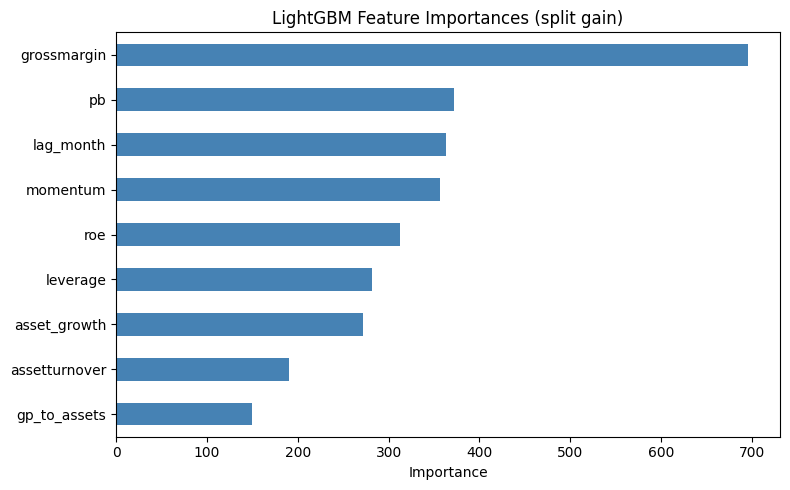

In [8]:
importances = pd.Series(lgbm.feature_importances_, index=FEATURES).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
importances.plot.barh(ax=ax, color="steelblue")
ax.set_title("LightGBM Feature Importances (split gain)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## 4. Model comparison

In [9]:
print(f"{'Model':20s} {'Mean':>10s} {'Median':>10s}")
print("-" * 42)
for name, sp in [("Ridge", sp_ridge), ("Lasso", sp_lasso),
                  ("Random Forest", sp_rf), ("LightGBM", sp_lgbm)]:
    print(f"{name:20s} {sp.mean():10.4f} {sp.median():10.4f}")

Model                      Mean     Median
------------------------------------------
Ridge                    0.0521     0.0708
Lasso                    0.0515     0.0514
Random Forest            0.0641     0.0529
LightGBM                 0.0726     0.0722


LightGBM typically produces the best predictions due to its ability to capture nonlinear interactions between features.